# 📊 Unemployment Analysis with Python


**Author:** Aleesha Nadeem

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn


# 📖 Introduction

Unemployment is one of the most important economic indicators that reflects the health of a country's economy.

The COVID-19 pandemic significantly affected employment across different regions and industries, leading to noticeable changes in unemployment rates.

In this project, we analyze unemployment data using Python to identify trends, compare unemployment across regions, and gain meaningful insights through data visualization.


# 🎯 Objectives

The objectives of this project are:

- Understand the unemployment dataset.
- Perform data cleaning.
- Explore unemployment trends.
- Visualize unemployment patterns.
- Generate meaningful business insights.


# Import Libraries 

In [1]:
import warnings 
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset


In [2]:

df = pd.read_csv("/kaggle/input/datasets/gokulrajkmv/unemployment-in-india/Unemployment in India.csv")
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


#  Basic Data Exploration

Before performing analysis, it is important to understand the dataset.

We will examine:

- Dataset shape
- Column names
- Data types
- Statistical summary
- Missing values

In [3]:
 df.shape

(768, 7)

In [4]:
print("Column Names", df.columns)

Column Names Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


In [5]:
print("Dataset Information")

df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [6]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


# Data Cleaning

Before analysis, we clean the dataset by:

- Removing unnecessary spaces from column names
- Checking missing values
- Removing missing records

In [7]:
# Remove Extra Spaces

df.columns = df.columns.str.strip()

df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [8]:
df.isnull().sum()

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

In [9]:
#  remove missing value 
df = df.dropna()

print(df.shape)

(740, 7)


In [10]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [11]:
df["Date"] = pd.to_datetime(df["Date"])

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 46.2+ KB


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand the dataset through visualizations and statistical summaries.

The objective is to identify trends, patterns, regional differences, and relationships between unemployment, employment, and labour participation.

## Distribution of Unemployment Rate

This histogram shows how unemployment rates are distributed across all observations.

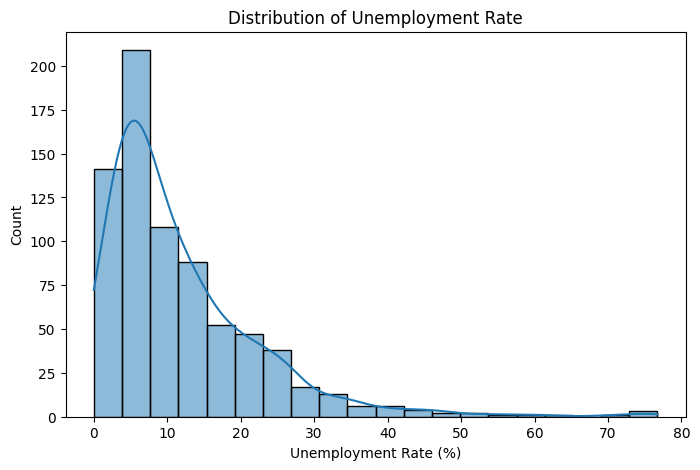

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Estimated Unemployment Rate (%)"],
    bins=20,
    kde=True
)

plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Count")

plt.show()

###  Insight

- Most unemployment rates are concentrated within a particular range.
- A few observations show relatively high unemployment, indicating possible economic stress in some regions.




##  Urban vs Rural Unemployment

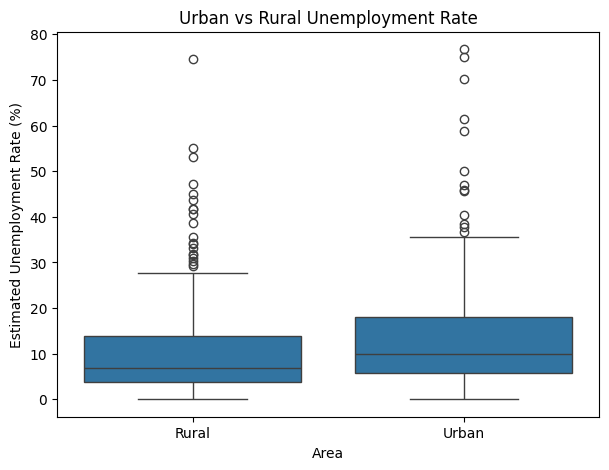

In [13]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Area",
    y="Estimated Unemployment Rate (%)"
)

plt.title("Urban vs Rural Unemployment Rate")

plt.show()

### 📌 Insight

- This visualization compares unemployment rates between urban and rural areas.
- Differences in median values and spread indicate variations in employment opportunities.





##  Top 10 Regions with Highest Unemployment

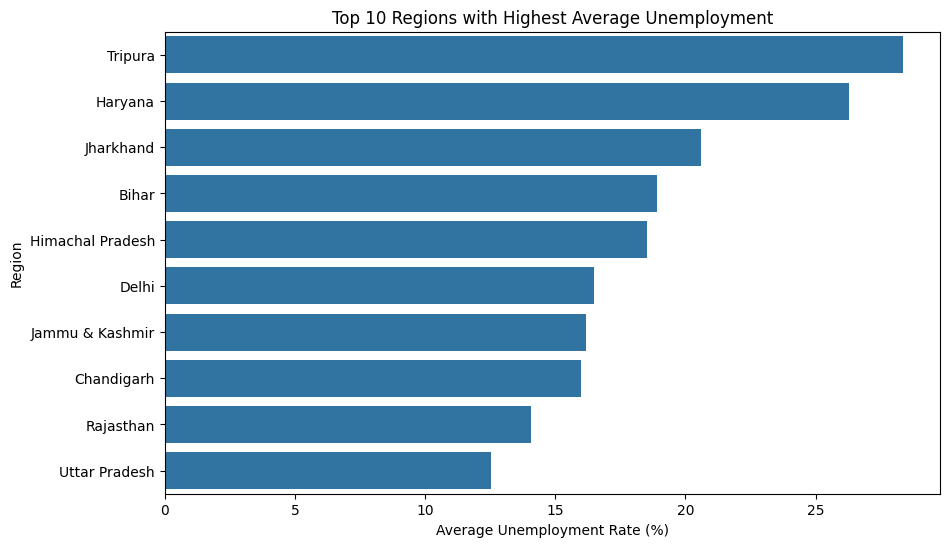

In [14]:
top_regions = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_regions.values,
    y=top_regions.index
)

plt.title("Top 10 Regions with Highest Average Unemployment")

plt.xlabel("Average Unemployment Rate (%)")

plt.show()

###  Insight

- Some regions consistently report higher unemployment than others.
- These regions may require focused economic and employment policies.


##  Top 10 Regions by Estimated Employment

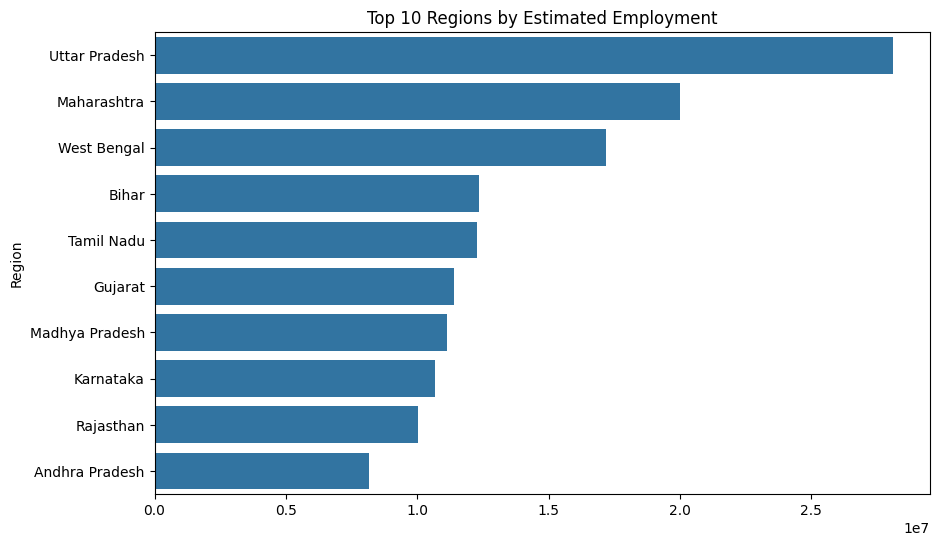

In [15]:
employment = (
    df.groupby("Region")["Estimated Employed"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=employment.values,
    y=employment.index
)

plt.title("Top 10 Regions by Estimated Employment")

plt.show()

##  Labour Participation Rate

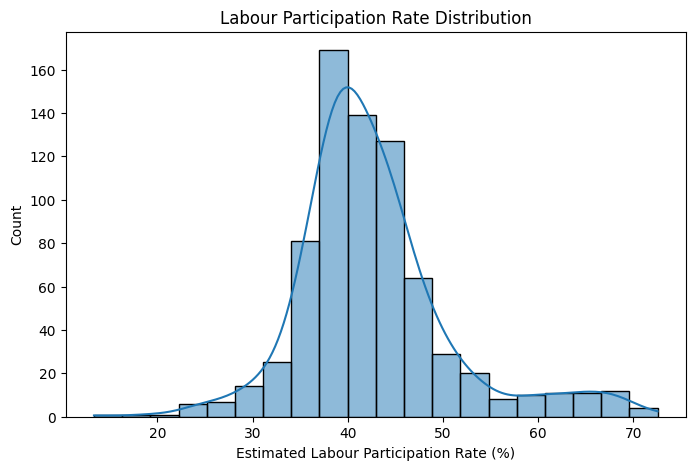

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Estimated Labour Participation Rate (%)"],
    bins=20,
    kde=True
)

plt.title("Labour Participation Rate Distribution")

plt.show()

###  Insight

- Labour participation varies across regions.
- A higher participation rate does not always indicate lower unemployment.

##  Correlation Heatmap

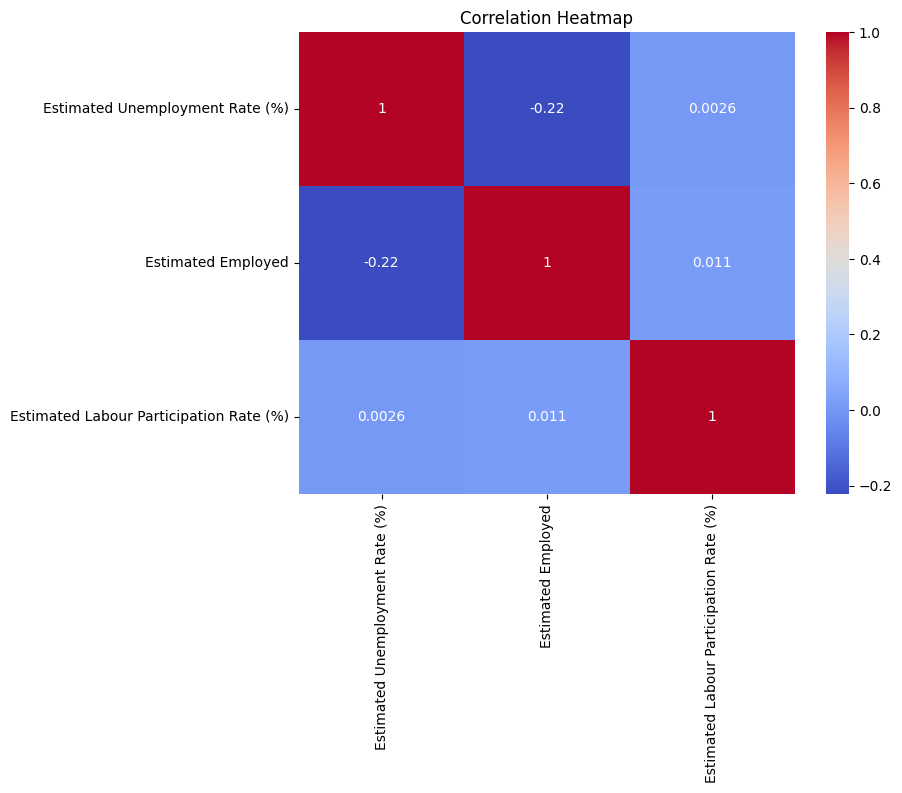

In [17]:
plt.figure(figsize=(8,6))

numeric = df.select_dtypes(include="number")

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

###  Insight

- The heatmap highlights positive and negative relationships among numerical variables.
- It helps identify which variables move together.




##  Monthly Trend

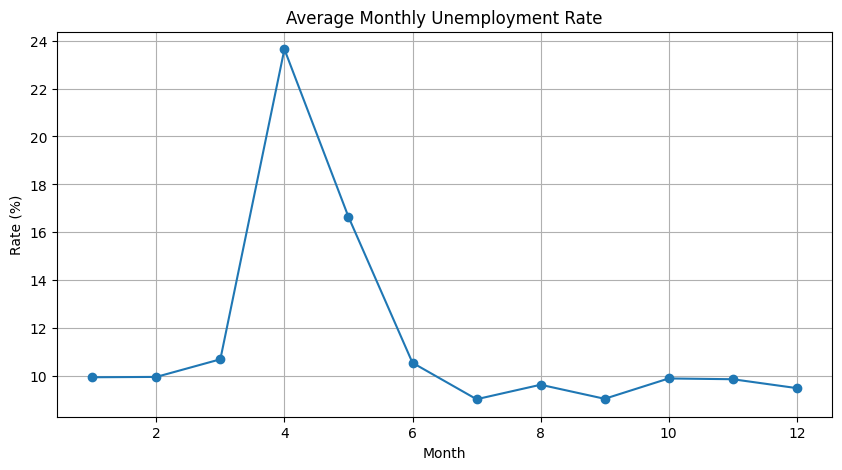

In [18]:
monthly = (
    df.groupby(df["Date"].dt.month)["Estimated Unemployment Rate (%)"]
      .mean()
)

plt.figure(figsize=(10,5))

monthly.plot(marker="o")

plt.title("Average Monthly Unemployment Rate")

plt.xlabel("Month")

plt.ylabel("Rate (%)")

plt.grid(True)

plt.show()

## Employment vs Unemployment

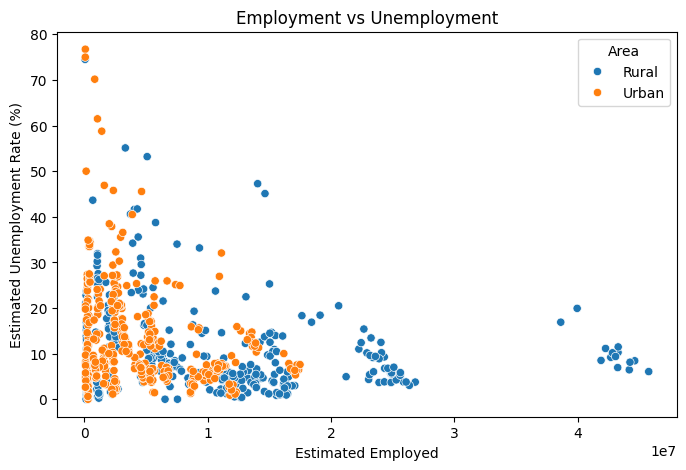

In [19]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Estimated Employed",
    y="Estimated Unemployment Rate (%)",
    hue="Area"
)

plt.title("Employment vs Unemployment")

plt.show()

###  Insight

- This graph shows the relationship between employment and unemployment.
- Different colors help compare urban and rural observations.

##  Pairplot

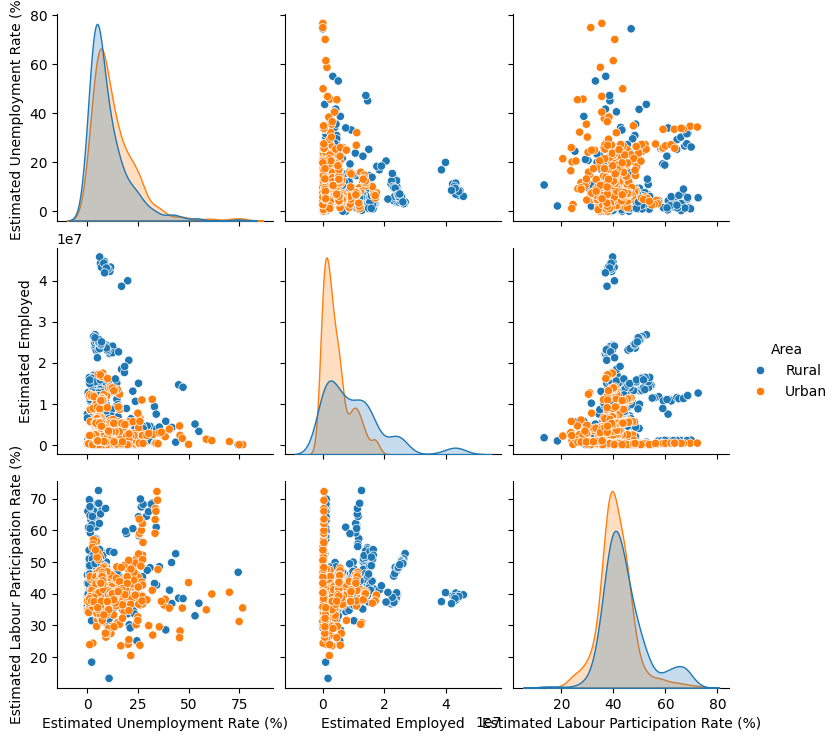

In [20]:
sns.pairplot(
    df[
        [
            "Estimated Unemployment Rate (%)",
            "Estimated Employed",
            "Estimated Labour Participation Rate (%)",
            "Area"
        ]
    ],
    hue="Area"
)

plt.show()

###  Insight

- Pairplots reveal relationships between numerical variables.
- They help identify clusters and trends across urban and rural areas.

##  Region-wise Average Unemployment

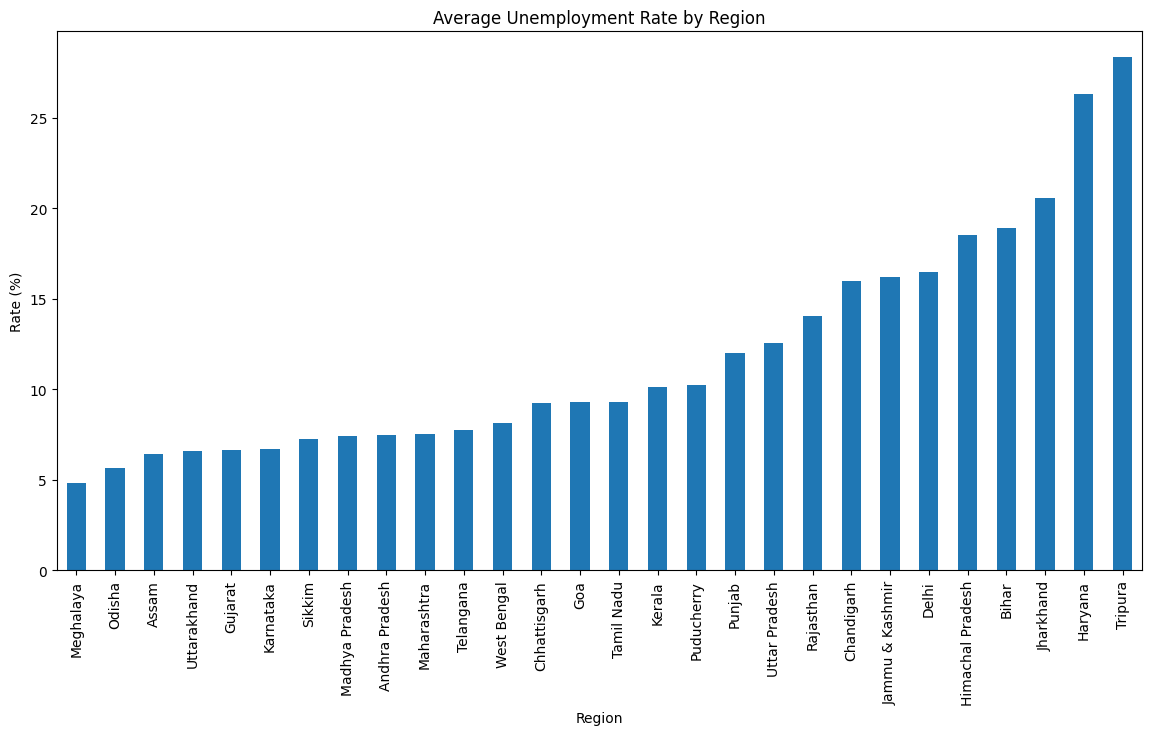

In [21]:
plt.figure(figsize=(14,7))

region = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
      .mean()
      .sort_values()
)

region.plot(kind="bar")

plt.title("Average Unemployment Rate by Region")

plt.ylabel("Rate (%)")

plt.xticks(rotation=90)

plt.show()

###  Insight

- Unemployment rates vary significantly across regions.
- Some regions consistently maintain lower unemployment levels than others.

#  EDA Summary

Key findings from the analysis:

- The dataset contains unemployment information from multiple regions.
- Missing values were removed during data cleaning.
- Unemployment rates vary considerably across regions.
- Urban and rural areas show different unemployment patterns.
- Employment and labour participation provide valuable context when analyzing unemployment.
- Correlation analysis highlights relationships among numerical variables.
- Monthly trends indicate that unemployment changes over time rather than remaining constant.
- Regional analysis suggests economic differences across the country.

These insights provide a strong foundation for understanding unemployment trends and can support data-driven decision-making.